In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df=pd.read_csv("/content/heart_disease_data.csv")

print("Dataset loaded successfully!")
print("Shape od dataset:",df.shape)
df.head()

Dataset loaded successfully!
Shape od dataset: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


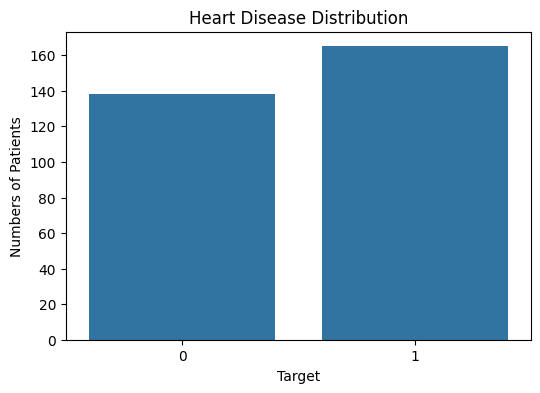

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='target',data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Numbers of Patients")
plt.show()

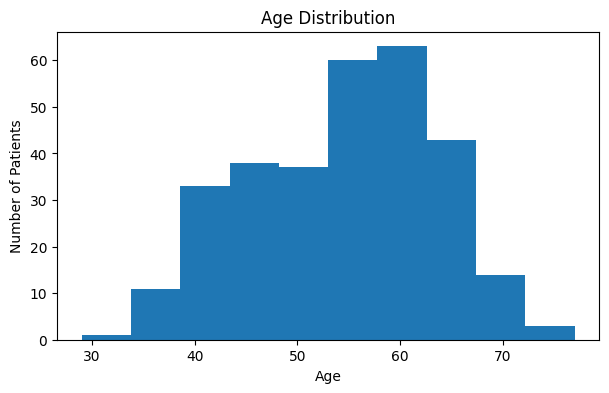

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(df['age'],bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


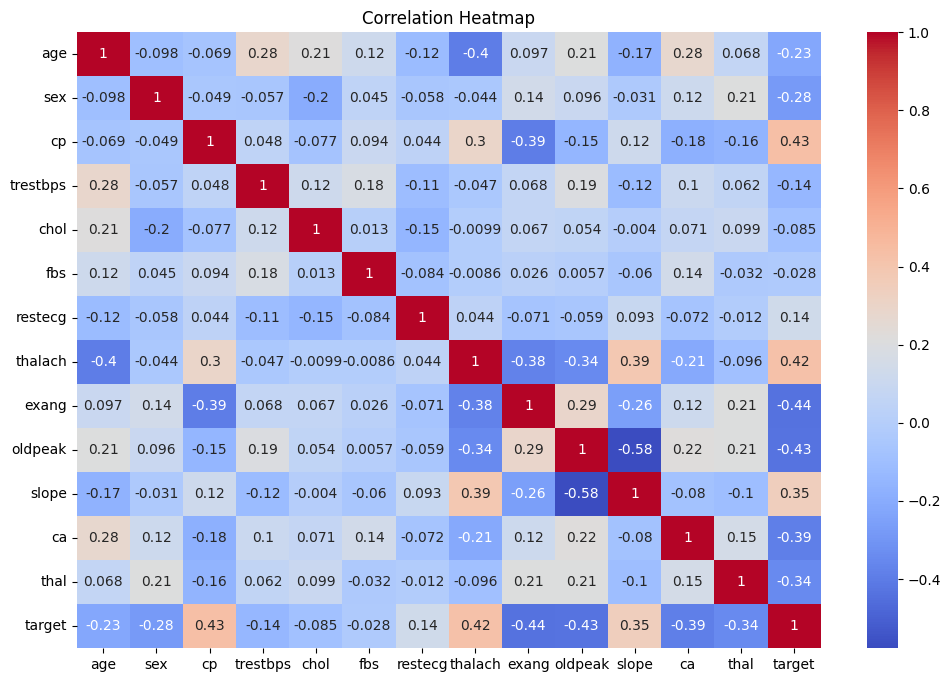

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X=df.drop('target',axis=1)
y=df['target']

print("Input features:",X.shape)
print("Target:",y.shape)


Input features: (303, 13)
Target: (303,)


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Traning data:",X_train.shape)
print("Testing data:",X_test.shape)

Traning data: (242, 13)
Testing data: (61, 13)


In [ ]:
scaler=StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [ ]:
model=LogisticRegression()

model.fit(X_train,y_train)

print("Model traning completed!")

Model traning completed!


In [ ]:
y_pred=model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 0 1 0 0 0 1 0
 1 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1]


In [ ]:
accuracy=accuracy_score(y_test,y_pred)

print("Model Accuracy:",accuracy)
print("Accuracy Percentage:",accuracy*100,"%")

Model Accuracy: 0.8032786885245902
Accuracy Percentage: 80.32786885245902 %


In [ ]:
cm=confusion_matrix(y_test,y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[19  9]
 [ 3 30]]


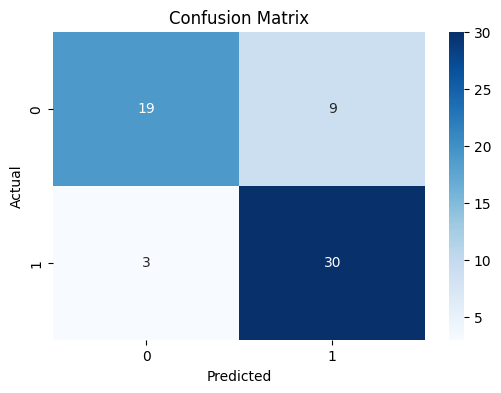

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
            annot=True,
            fmt='d',
            cmap='Blues'
            )

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



In [ ]:
print("Enter patient details")

age = float(input("Age: "))
sex = float(input("Sex (0 = Female, 1 = Male): "))
cp = float(input("Chest Pain Type (0-3): "))
trestbps = float(input("Resting Blood Pressure: "))
chol = float(input("Cholesterol: "))
fbs = float(input("Fasting Blood Sugar (0/1): "))
restecg = float(input("Resting ECG (0-2): "))
thalach = float(input("Maximum Heart Rate: "))
exang = float(input("Exercise Induced Angina (0/1): "))
oldpeak = float(input("Oldpeak: "))
slope = float(input("Slope (0-2): "))
ca = float(input("Number of Major Vessels (0-3): "))
thal = float(input("Thal (0-3): "))

patient = np.array([[
    age, sex, cp, trestbps, chol, fbs,
    restecg, thalach, exang, oldpeak,
    slope, ca, thal
]])

patient_scaled = scaler.transform(patient)

prediction = model.predict(patient_scaled)

if prediction[0] == 1:
    print("\nPrediction: Positive class")
else:
    print("\nPrediction: Negative class")


Enter patient details
Age: 20
Sex (0 = Female, 1 = Male): 0
Chest Pain Type (0-3): 2
Resting Blood Pressure: 120
Cholesterol: 200
Fasting Blood Sugar (0/1): 0
Resting ECG (0-2): 0
Maximum Heart Rate: 170
Exercise Induced Angina (0/1): 0
Oldpeak: 0.5
Slope (0-2): 1
Number of Major Vessels (0-3): 2
Thal (0-3): 2

Prediction: Positive class


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
